Which Real Estate Investment Vehicle Is Best at Present? A Data-Driven Rule-Based Decision Framework

Framework:
This model compares three real-estate vehicle TYPES, not three identical tradable securities.
The framework uses observable ETF data for the listed REIT vehicle and macro-financial rules for non-listed vehicles.
The final score is a weighted sum of five dimensions scored on a 0-100 basis.

Weight table:
                    Dimension Weight
                       Income    20%
                  Performance    20%
  Liquidity & Diversification    20%
         Financing Resilience    25%
Implementation & Transparency    15%

Question:
Which real estate investment vehicle is best at present?

Observed market inputs:
Latest 10Y Treasury yield: 4.15%
Average 10Y Treasury yield over the last ~1 year: 4.23%
Latest 30Y mortgage rate: 6.00%
Average 30Y mortgage rate over the last ~1 year: 6.45%
30Y mortgage rate change over ~12 weeks: -0.22 percentage points
Latest federal debt-to-GDP

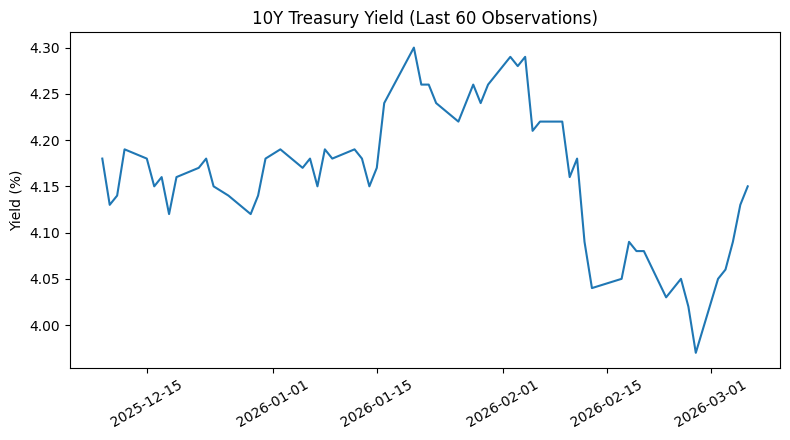

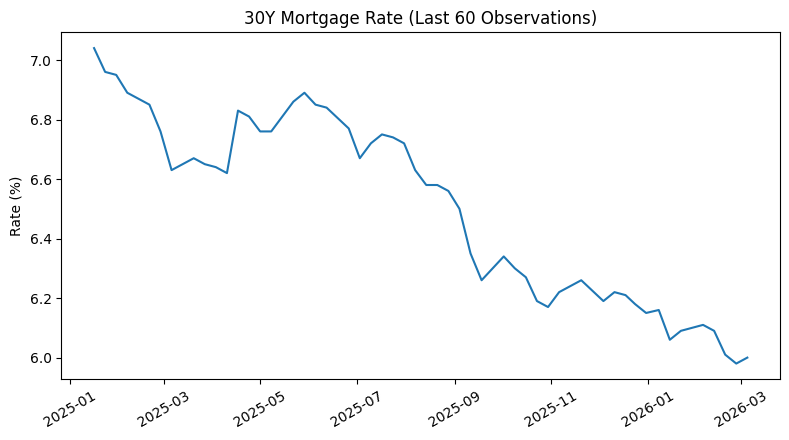

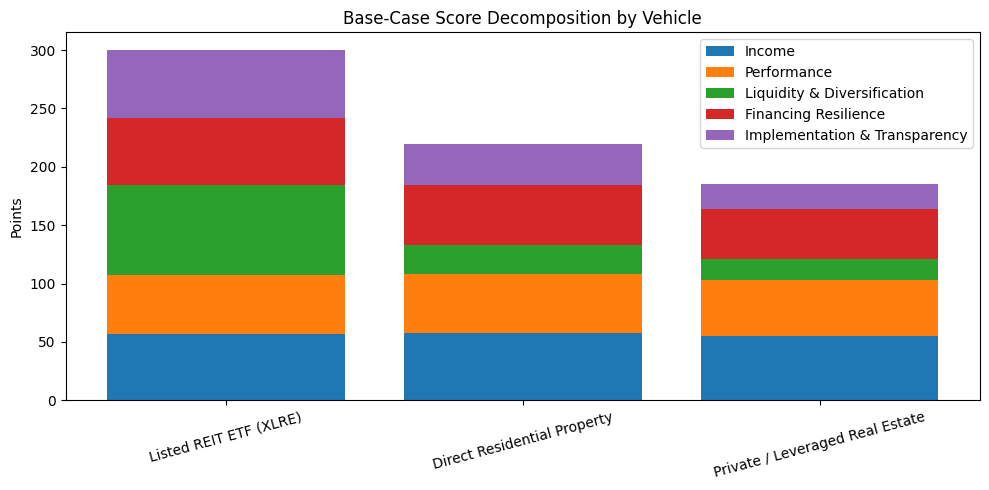

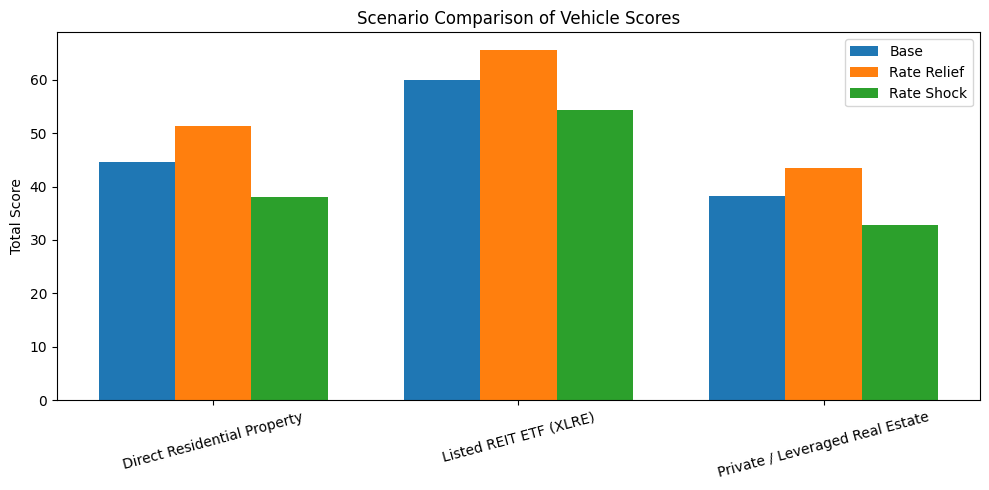

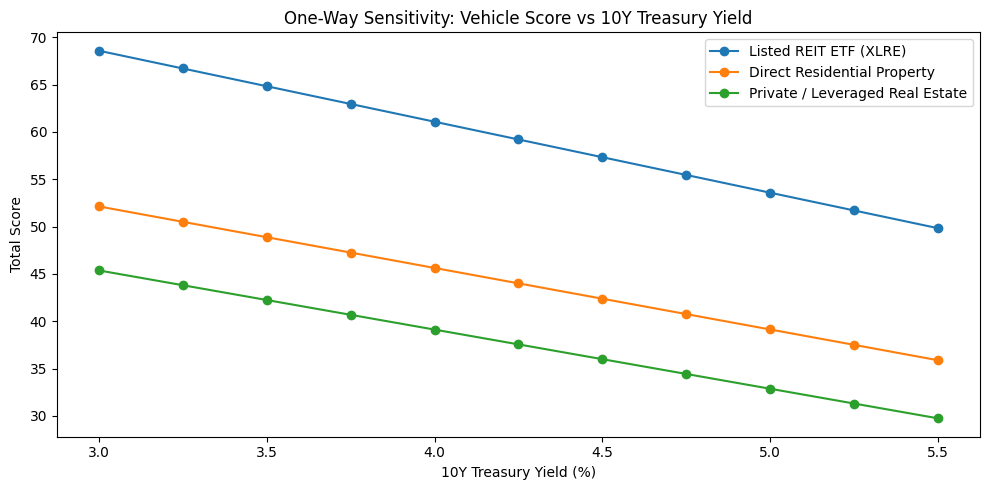


Final answer:
At present, the best real estate investment vehicle is: Listed REIT ETF (XLRE).
This result is strongest because the listed REIT vehicle combines observable yield, positive medium-term performance, superior liquidity, diversification, and easier implementation.
Direct residential property and private / leveraged real estate remain more exposed to financing cost, refinancing pressure, illiquidity, and execution difficulty.
The scenario analysis also shows that the same vehicle remains top-ranked in the base case, rate-relief case, and rate-shock case.

Project title:
Which Real Estate Investment Vehicle Is Best at Present? A Data-Driven Rule-Based Decision Framework

Final recommendation:
Listed REIT ETF (XLRE)

Why this version is more professional:
1. It uses an explicit five-dimension scoring framework.
2. It explains the weights instead of using hidden penalties only.
3. It includes base case, rate-relief, and rate-shock scenarios.
4. It includes one-way sensitivity a

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TITLE = "Which Real Estate Investment Vehicle Is Best at Present? A Data-Driven Rule-Based Decision Framework"

def locate_file(filename):
    roots = [
        Path.cwd(),
        Path.cwd() / "FINT400",
        Path.cwd() / "FIN446",
        Path.home() / "Desktop" / "FINT400",
        Path.home() / "Desktop" / "FIN446",
        Path("/mnt/data"),
    ]
    for root in roots:
        candidate = root / filename
        if candidate.exists():
            return candidate
    for root in roots:
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                return matches[0]
    raise FileNotFoundError(f"Cannot find {filename}. Put it in Desktop/FINT400 or Desktop/FIN446.")

def read_fred_excel(filename, value_name):
    path = locate_file(filename)
    df = pd.read_excel(path)
    df.columns = ["date", value_name]
    df = df.iloc[1:].copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    return df.dropna().sort_values("date")

def bounded_score(x, low, high, reverse=False):
    x = float(x)
    if high == low:
        return 50.0
    value = (x - low) / (high - low) * 100
    if reverse:
        value = 100 - value
    return float(np.clip(value, 0, 100))

def pct(x):
    return f"{x:.2%}"

def num(x):
    return f"{x:,.2f}"

print(TITLE)

# =========================
# 1. LOAD MACRO DATA
# =========================
dgs10 = read_fred_excel("DGS10(FIN446).xlsx", "DGS10")
mortgage30 = read_fred_excel("MORTGAGE30US(FIN446).xlsx", "MORTGAGE30US")
debt_gdp = read_fred_excel("GFDEGDQ188S(FIN446).xlsx", "GFDEGDQ188S")

latest_10y = float(dgs10["DGS10"].iloc[-1])
latest_mortgage = float(mortgage30["MORTGAGE30US"].iloc[-1])
latest_debt = float(debt_gdp["GFDEGDQ188S"].iloc[-1])

avg_10y_1y = float(dgs10["DGS10"].tail(min(252, len(dgs10))).mean())
avg_mortgage_1y = float(mortgage30["MORTGAGE30US"].tail(min(52, len(mortgage30))).mean())
mortgage_12w_change = float(latest_mortgage - mortgage30["MORTGAGE30US"].iloc[-13]) if len(mortgage30) >= 13 else np.nan

# =========================
# 2. LOAD ETF DATA
# =========================
panel_raw = pd.read_excel(locate_file("three_etf_performance(FINT400).xlsx"), sheet_name="Panel_Ready", header=None)
panel = panel_raw.iloc[3:].copy()
panel.columns = panel_raw.iloc[2]
panel = panel.reset_index(drop=True)

for col in ["1 Month", "QTD", "YTD", "1 Year", "3 Year", "5 Year", "10 Year", "Since Inception"]:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

fund_long = pd.read_excel(locate_file("etf_fund_data_mar10_2026(FINT400).xlsx"), sheet_name="Data_Long")
product = pd.read_excel(locate_file("spdr-product-data-us-en(FINT400).xlsx"), header=1).dropna(how="all")

def get_metric(fund, metric):
    s = fund_long[(fund_long["Fund"] == fund) & (fund_long["Metric"] == metric)]["Value"]
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s):
        return float(s.iloc[0])
    return np.nan

xlre_1y = float(panel.loc[panel["ETF"] == "XLRE", "1 Year"].iloc[0])
xlre_3y = float(panel.loc[panel["ETF"] == "XLRE", "3 Year"].iloc[0])
xlre_5y = float(panel.loc[panel["ETF"] == "XLRE", "5 Year"].iloc[0])

xlre_yield = get_metric("XLRE", "Fund Distribution Yield")
xlre_sec_yield = get_metric("XLRE", "30 Day SEC Yield")
xlre_pe = get_metric("XLRE", "Price/Earnings Ratio FY1")
xlre_holdings = get_metric("XLRE", "Number of Holdings")
xlre_wavg_mcap = get_metric("XLRE", "Weighted Average Market Cap ($M)")

xlre_product_row = product[product["Ticker"] == "XLRE"].iloc[0]
xlre_expense = float(str(xlre_product_row["Gross Expense Ratio"]).replace("%", "").strip()) / 100
xlre_aum = float(
    str(xlre_product_row["Total Net Assets"])
    .replace("$", "")
    .replace(",", "")
    .replace(" M", "")
    .strip()
)

# =========================
# 3. DEFINE A MORE PROFESSIONAL FRAMEWORK
# =========================
print("\nFramework:")
print("This model compares three real-estate vehicle TYPES, not three identical tradable securities.")
print("The framework uses observable ETF data for the listed REIT vehicle and macro-financial rules for non-listed vehicles.")
print("The final score is a weighted sum of five dimensions scored on a 0-100 basis.")

weights = {
    "Income": 0.20,
    "Performance": 0.20,
    "Liquidity & Diversification": 0.20,
    "Financing Resilience": 0.25,
    "Implementation & Transparency": 0.15,
}

weight_table = pd.DataFrame({
    "Dimension": list(weights.keys()),
    "Weight": list(weights.values())
})
weight_table["Weight"] = weight_table["Weight"].map(lambda x: f"{x:.0%}")
print("\nWeight table:")
print(weight_table.to_string(index=False))

def score_listed_reit(y10, mortgage_rate):
    income = 0.55 * bounded_score(xlre_yield, 0.01, 0.05) + 0.45 * bounded_score(xlre_sec_yield, 0.01, 0.05)
    performance = 0.55 * bounded_score(xlre_3y, 0.00, 0.12) + 0.45 * bounded_score(xlre_5y, 0.00, 0.12)
    liquidity = (
        0.50 * 95
        + 0.25 * bounded_score(xlre_holdings, 15, 50)
        + 0.25 * bounded_score(xlre_aum, 1000, 10000)
    )
    financing = 0.75 * bounded_score(y10, 3.0, 5.5, reverse=True) + 0.25 * 65
    implementation = (
        0.40 * bounded_score(xlre_pe, 15, 40, reverse=True)
        + 0.30 * bounded_score(xlre_expense, 0.0005, 0.0060, reverse=True)
        + 0.15 * 95
        + 0.15 * bounded_score(xlre_wavg_mcap, 10000, 80000)
    )
    return {
        "Income": income,
        "Performance": performance,
        "Liquidity & Diversification": liquidity,
        "Financing Resilience": financing,
        "Implementation & Transparency": implementation,
    }

def score_direct_property(y10, mortgage_rate):
    income = 56
    if mortgage_12w_change < 0:
        income += 2
    performance = 50
    liquidity = 25
    financing = 0.70 * bounded_score(mortgage_rate, 4.0, 8.0, reverse=True) + 0.30 * bounded_score(y10, 3.0, 5.5, reverse=True)
    implementation = 35
    return {
        "Income": income,
        "Performance": performance,
        "Liquidity & Diversification": liquidity,
        "Financing Resilience": financing,
        "Implementation & Transparency": implementation,
    }

def score_private_leveraged(y10, mortgage_rate, debt_ratio):
    income = 55
    performance = 48
    liquidity = 18
    financing = (
        0.50 * bounded_score(y10, 3.0, 5.5, reverse=True)
        + 0.25 * bounded_score(mortgage_rate, 4.0, 8.0, reverse=True)
        + 0.25 * bounded_score(debt_ratio, 70, 130, reverse=True)
    )
    implementation = 22
    return {
        "Income": income,
        "Performance": performance,
        "Liquidity & Diversification": liquidity,
        "Financing Resilience": financing,
        "Implementation & Transparency": implementation,
    }

def total_score(component_scores):
    return sum(component_scores[k] * weights[k] for k in weights)

def evaluate_scenario(y10, mortgage_rate, debt_ratio, scenario_name):
    components = {
        "Listed REIT ETF (XLRE)": score_listed_reit(y10, mortgage_rate),
        "Direct Residential Property": score_direct_property(y10, mortgage_rate),
        "Private / Leveraged Real Estate": score_private_leveraged(y10, mortgage_rate, debt_ratio),
    }
    rows = []
    for vehicle, comp in components.items():
        row = {"Scenario": scenario_name, "Vehicle": vehicle}
        row.update(comp)
        row["Total Score"] = total_score(comp)
        rows.append(row)
    return pd.DataFrame(rows)

# =========================
# 4. BASE CASE
# =========================
base_df = evaluate_scenario(latest_10y, latest_mortgage, latest_debt, "Base").sort_values("Total Score", ascending=False).reset_index(drop=True)
winner = base_df.loc[0, "Vehicle"]

print("\nQuestion:")
print("Which real estate investment vehicle is best at present?")

print("\nObserved market inputs:")
print(f"Latest 10Y Treasury yield: {latest_10y:.2f}%")
print(f"Average 10Y Treasury yield over the last ~1 year: {avg_10y_1y:.2f}%")
print(f"Latest 30Y mortgage rate: {latest_mortgage:.2f}%")
print(f"Average 30Y mortgage rate over the last ~1 year: {avg_mortgage_1y:.2f}%")
print(f"30Y mortgage rate change over ~12 weeks: {mortgage_12w_change:.2f} percentage points")
print(f"Latest federal debt-to-GDP ratio: {latest_debt:.2f}%")

print("\nObserved XLRE evidence:")
print(f"XLRE 1-year return: {pct(xlre_1y)}")
print(f"XLRE 3-year return: {pct(xlre_3y)}")
print(f"XLRE 5-year return: {pct(xlre_5y)}")
print(f"XLRE fund distribution yield: {pct(xlre_yield)}")
print(f"XLRE 30-day SEC yield: {pct(xlre_sec_yield)}")
print(f"XLRE forward P/E ratio: {num(xlre_pe)}")
print(f"XLRE number of holdings: {int(xlre_holdings)}")
print(f"XLRE gross expense ratio: {pct(xlre_expense)}")
print(f"XLRE total net assets: US${num(xlre_aum)}M")

display_base = base_df.copy()
for col in ["Income", "Performance", "Liquidity & Diversification", "Financing Resilience", "Implementation & Transparency", "Total Score"]:
    display_base[col] = display_base[col].map(lambda x: f"{x:.2f}")

print("\nBase-case scorecard:")
print(display_base.to_string(index=False))

# =========================
# 5. SCENARIO ANALYSIS
# =========================
scenario_inputs = {
    "Base": {"y10": latest_10y, "mortgage": latest_mortgage, "debt": latest_debt},
    "Rate Relief": {"y10": max(2.50, latest_10y - 0.75), "mortgage": max(4.00, latest_mortgage - 1.00), "debt": latest_debt},
    "Rate Shock": {"y10": min(6.00, latest_10y + 0.75), "mortgage": min(8.50, latest_mortgage + 1.00), "debt": latest_debt},
}

scenario_frames = []
for scenario_name, vals in scenario_inputs.items():
    scenario_frames.append(evaluate_scenario(vals["y10"], vals["mortgage"], vals["debt"], scenario_name))
scenario_df = pd.concat(scenario_frames, ignore_index=True)
scenario_rank = scenario_df.sort_values(["Scenario", "Total Score"], ascending=[True, False]).copy()
scenario_rank["Rank"] = scenario_rank.groupby("Scenario")["Total Score"].rank(ascending=False, method="dense").astype(int)

display_scenario = scenario_rank[["Scenario", "Vehicle", "Total Score", "Rank"]].copy()
display_scenario["Total Score"] = display_scenario["Total Score"].map(lambda x: f"{x:.2f}")

print("\nScenario analysis:")
for scenario_name, vals in scenario_inputs.items():
    print(f"{scenario_name}: 10Y={vals['y10']:.2f}%, Mortgage={vals['mortgage']:.2f}%")
print(display_scenario.to_string(index=False))

# =========================
# 6. RATE SENSITIVITY
# =========================
rate_grid = np.linspace(3.00, 5.50, 11)
sensitivity_rows = []
for y10 in rate_grid:
    implied_mortgage = latest_mortgage + 0.80 * (y10 - latest_10y)
    current_df = evaluate_scenario(y10, implied_mortgage, latest_debt, f"10Y={y10:.2f}")
    for _, row in current_df.iterrows():
        sensitivity_rows.append({
            "10Y Treasury Yield": y10,
            "Implied Mortgage Rate": implied_mortgage,
            "Vehicle": row["Vehicle"],
            "Total Score": row["Total Score"]
        })
sensitivity_df = pd.DataFrame(sensitivity_rows)

# =========================
# 7. SAVE CHARTS FOR GITHUB / REPORT USE
# =========================
output_dir = Path.cwd() / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

# Chart 1: 10Y Treasury Yield
plt.figure(figsize=(8, 4.5))
plt.plot(dgs10["date"].tail(60), dgs10["DGS10"].tail(60))
plt.title("10Y Treasury Yield (Last 60 Observations)")
plt.ylabel("Yield (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(output_dir / "treasury_yield_last_60.png", dpi=200, bbox_inches="tight")
plt.show()

# Chart 2: 30Y Mortgage Rate
plt.figure(figsize=(8, 4.5))
plt.plot(mortgage30["date"].tail(60), mortgage30["MORTGAGE30US"].tail(60))
plt.title("30Y Mortgage Rate (Last 60 Observations)")
plt.ylabel("Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(output_dir / "mortgage_rate_last_60.png", dpi=200, bbox_inches="tight")
plt.show()

# Chart 3: Base-case score decomposition
decomp = base_df.set_index("Vehicle")[["Income", "Performance", "Liquidity & Diversification", "Financing Resilience", "Implementation & Transparency"]]
plt.figure(figsize=(10, 5))
bottom = np.zeros(len(decomp))
for col in decomp.columns:
    plt.bar(decomp.index, decomp[col], bottom=bottom, label=col)
    bottom += decomp[col].values
plt.title("Base-Case Score Decomposition by Vehicle")
plt.ylabel("Points")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "base_case_score_decomposition.png", dpi=200, bbox_inches="tight")
plt.show()

# Chart 4: Scenario total score comparison
scenario_pivot = scenario_df.pivot(index="Vehicle", columns="Scenario", values="Total Score")[["Base", "Rate Relief", "Rate Shock"]]
x = np.arange(len(scenario_pivot.index))
width = 0.25
plt.figure(figsize=(10, 5))
for i, col in enumerate(scenario_pivot.columns):
    plt.bar(x + (i - 1) * width, scenario_pivot[col].values, width=width, label=col)
plt.xticks(x, scenario_pivot.index, rotation=15)
plt.ylabel("Total Score")
plt.title("Scenario Comparison of Vehicle Scores")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "scenario_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# Chart 5: One-way rate sensitivity
plt.figure(figsize=(10, 5))
for vehicle in sensitivity_df["Vehicle"].unique():
    tmp = sensitivity_df[sensitivity_df["Vehicle"] == vehicle]
    plt.plot(tmp["10Y Treasury Yield"], tmp["Total Score"], marker="o", label=vehicle)
plt.xlabel("10Y Treasury Yield (%)")
plt.ylabel("Total Score")
plt.title("One-Way Sensitivity: Vehicle Score vs 10Y Treasury Yield")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "rate_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()

# =========================
# 8. EXPORT TABLES FOR REPORTING
# =========================
base_df.to_csv(Path.cwd() / "base_case_scorecard.csv", index=False)
scenario_rank.to_csv(Path.cwd() / "scenario_ranking.csv", index=False)
sensitivity_df.to_csv(Path.cwd() / "rate_sensitivity_table.csv", index=False)

# =========================
# 9. FINAL INVESTMENT ANSWER
# =========================
print("\nFinal answer:")
print(f"At present, the best real estate investment vehicle is: {winner}.")
print("This result is strongest because the listed REIT vehicle combines observable yield, positive medium-term performance, superior liquidity, diversification, and easier implementation.")
print("Direct residential property and private / leveraged real estate remain more exposed to financing cost, refinancing pressure, illiquidity, and execution difficulty.")
print("The scenario analysis also shows that the same vehicle remains top-ranked in the base case, rate-relief case, and rate-shock case.")

summary_text = f"""
Project title:
{TITLE}

Final recommendation:
{winner}

Why this version is more professional:
1. It uses an explicit five-dimension scoring framework.
2. It explains the weights instead of using hidden penalties only.
3. It includes base case, rate-relief, and rate-shock scenarios.
4. It includes one-way sensitivity analysis against the 10Y Treasury yield.
5. It exports charts and CSV tables for GitHub and report use.

Files generated after running:
- figures/treasury_yield_last_60.png
- figures/mortgage_rate_last_60.png
- figures/base_case_score_decomposition.png
- figures/scenario_comparison.png
- figures/rate_sensitivity.png
- base_case_scorecard.csv
- scenario_ranking.csv
- rate_sensitivity_table.csv
"""
print(summary_text)
